In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

df = pd.read_csv("/content/report_2018-2019.csv")
print(df.shape)
print(df.info())
df.head()


(312, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  312 non-null    int64  
 1   Country or region             312 non-null    object 
 2   Year                          312 non-null    int64  
 3   Score                         312 non-null    float64
 4   GDP per capita                312 non-null    float64
 5   Social support                312 non-null    float64
 6   Healthy life expectancy       312 non-null    float64
 7   Freedom to make life choices  312 non-null    float64
 8   Generosity                    312 non-null    float64
 9   Perceptions of corruption     312 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 24.5+ KB
None


,Overall rank,Country or region,Year,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,154,Afghanistan,2019,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,145,Afghanistan,2018,3.632,0.332,0.537,0.255,0.085,0.191,0.036
2,107,Albania,2019,4.719,0.947,0.848,0.874,0.383,0.178,0.027
3,112,Albania,2018,4.586,0.916,0.817,0.790,0.419,0.149,0.032
4,88,Algeria,2019,5.211,1.002,1.160,0.785,0.086,0.073,0.114


In [ ]:
df.describe()

,Overall rank,Year,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000,312.000000
mean,78.500000,2018.500000,5.391506,0.898298,1.211026,0.661295,0.423538,0.182926,0.111526
std,45.104737,0.500803,1.114631,0.394592,0.300310,0.252724,0.156024,0.096739,0.095296
min,1.000000,2018.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,2018.000000,4.514250,0.609500,1.055750,0.488250,0.322500,0.108750,0.050000
50%,78.500000,2018.500000,5.379500,0.960000,1.265500,0.699000,0.449500,0.175500,0.082000
75%,117.250000,2019.000000,6.176000,1.219500,1.457500,0.858000,0.540250,0.245000,0.141250
max,156.000000,2019.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.598000,0.457000


In [ ]:
df.isnull().sum()


,0
Overall rank,0
Country or region,0
Year,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [ ]:
non_numeric = ['Country or region', 'Overall rank']
df = df.drop(columns=non_numeric, errors='ignore')


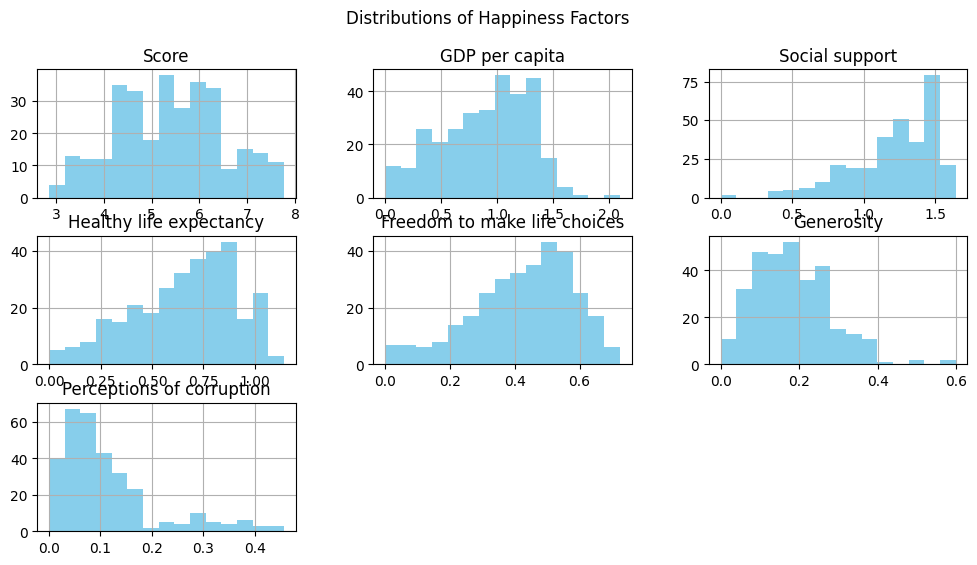

In [ ]:
cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

df[cols].hist(bins=15, figsize=(12,6), color='skyblue')
plt.suptitle("Distributions of Happiness Factors")
plt.show()


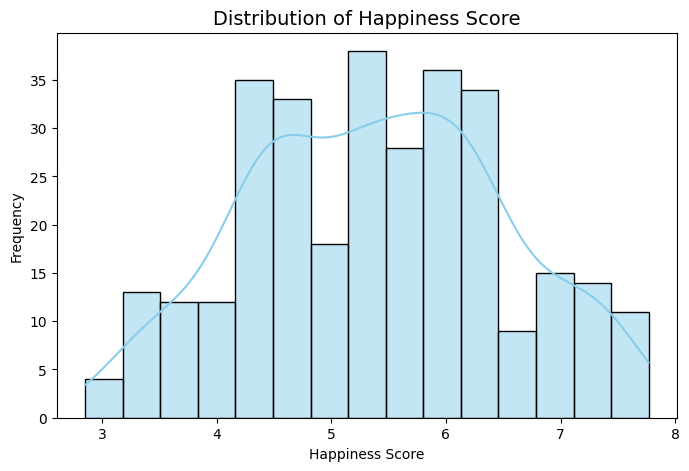

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Score', bins=15, color='skyblue', kde=True)
plt.title('Distribution of Happiness Score', fontsize=14)
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()


/tmp/ipython-input-4019309303.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df[col], y=df['Score'], color='skyblue', ci=None)
/tmp/ipython-input-4019309303.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df[col], y=df['Score'], color='skyblue', ci=None)
/tmp/ipython-input-4019309303.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df[col], y=df['Score'], color='skyblue', ci=None)
/tmp/ipython-input-4019309303.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=df[col], y=df['Score'], color='skyblue', ci=None)


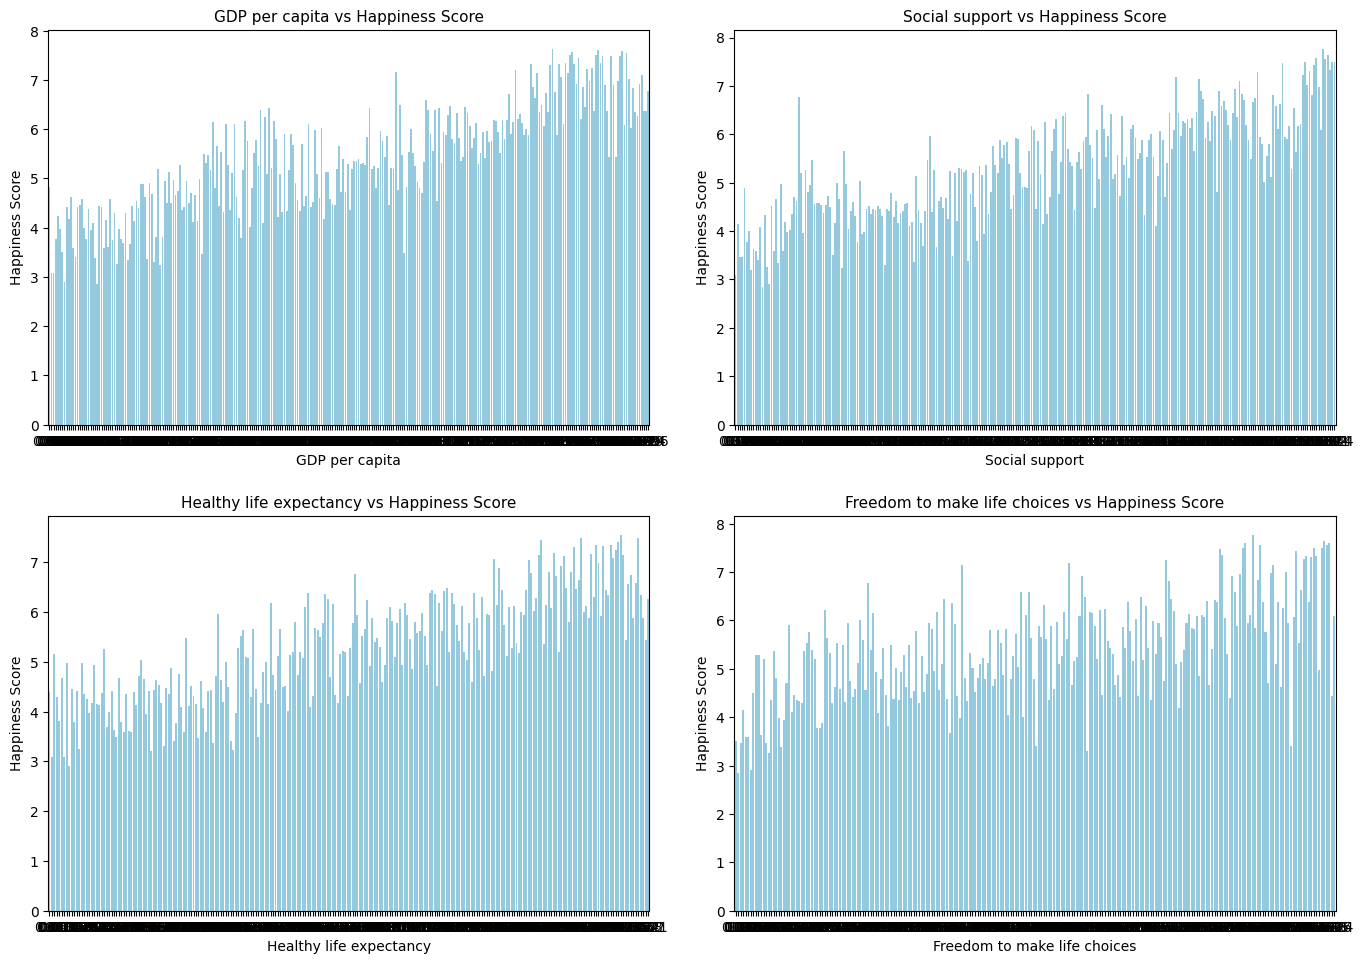

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

important_features = [
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(important_features, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=df[col], y=df['Score'], color='skyblue', ci=None)
    plt.title(f'{col} vs Happiness Score', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Happiness Score')

plt.tight_layout(pad=2)
plt.show()


/tmp/ipython-input-3157162170.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Happiness Category', data=df, palette='pastel')


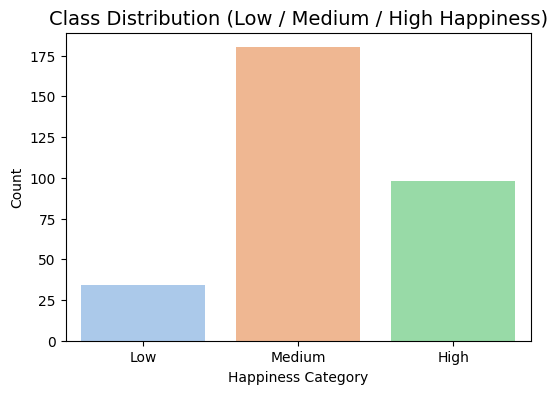

In [ ]:
# تقسيم Happiness Score إلى 3 فئات
df['Happiness Category'] = pd.cut(df['Score'],
                                  bins=[0, 4, 6, 10],
                                  labels=['Low', 'Medium', 'High'])

# نرسم التوزيع
plt.figure(figsize=(6,4))
sns.countplot(x='Happiness Category', data=df, palette='pastel')
plt.title('Class Distribution (Low / Medium / High Happiness)', fontsize=14)
plt.xlabel('Happiness Category')
plt.ylabel('Count')
plt.show()


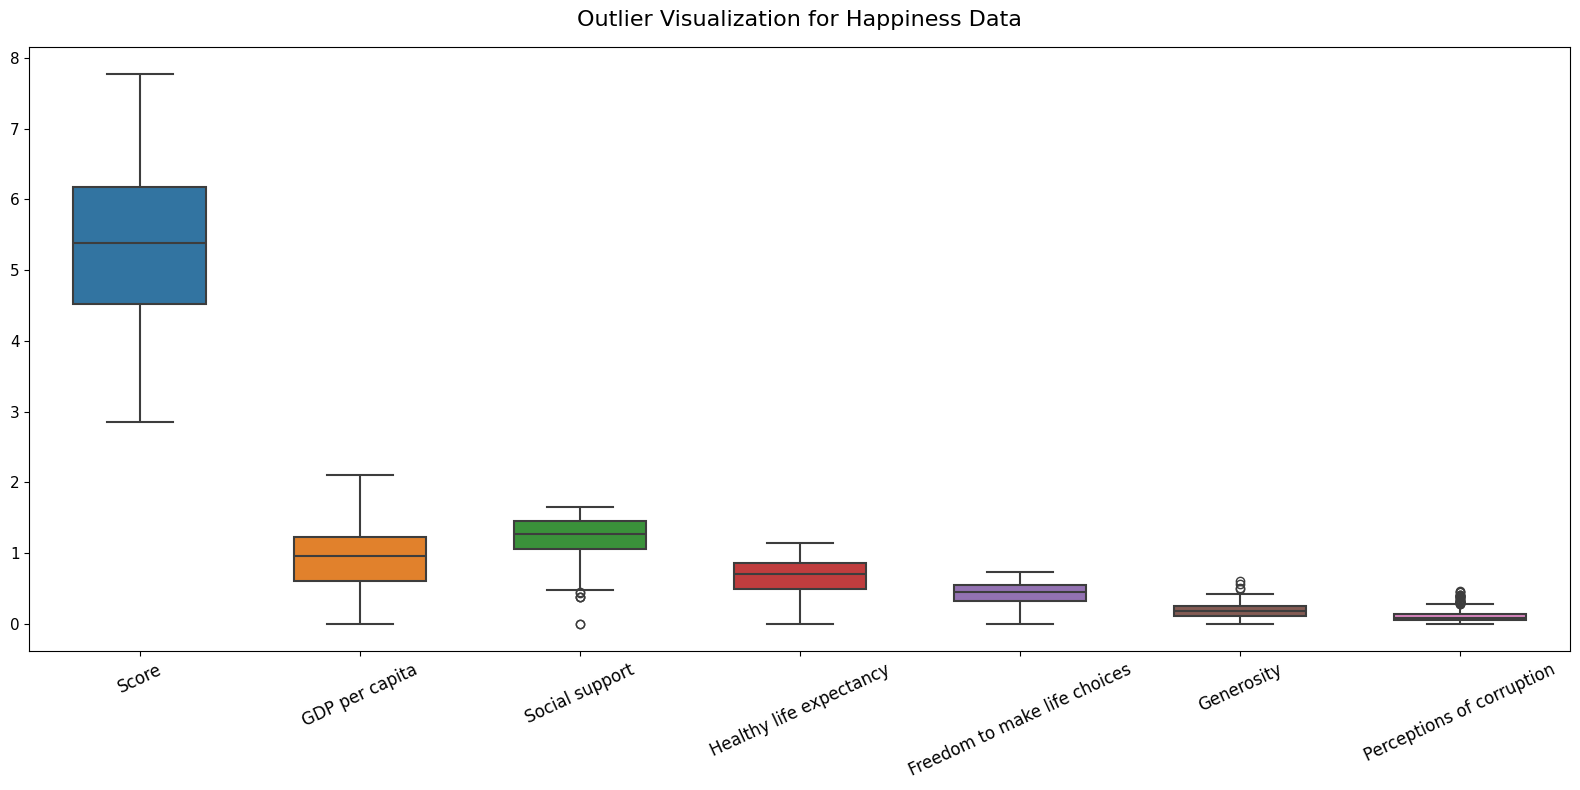

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

plt.figure(figsize=(16, 8))  # زيدي العرض والارتفاع
sns.boxplot(data=df[numeric_cols], width=0.6, linewidth=1.5)

plt.title('Outlier Visualization for Happiness Data', fontsize=16, pad=15)
plt.xticks(rotation=25, fontsize=12)
plt.yticks(fontsize=11)
plt.xlabel('')
plt.tight_layout()
plt.show()



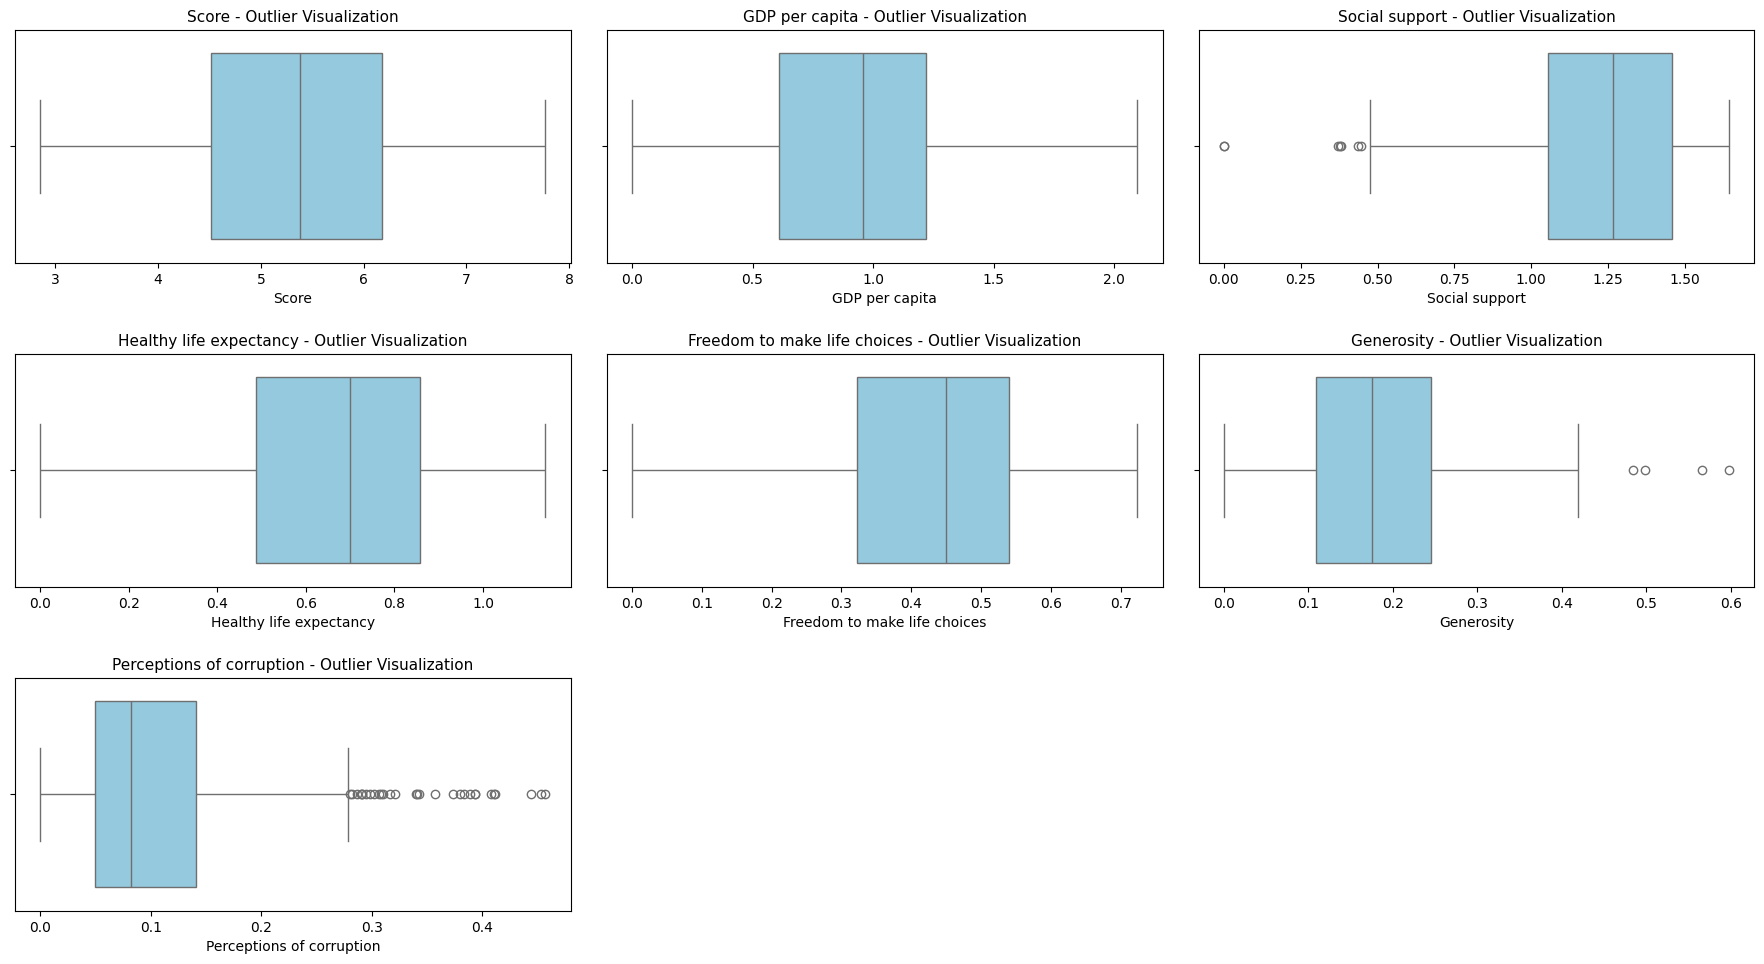

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'Score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

plt.figure(figsize=(18, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # 3 صفوف × 3 أعمدة لراحة العين
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'{col} - Outlier Visualization', fontsize=11)

plt.tight_layout(pad=2)
plt.show()


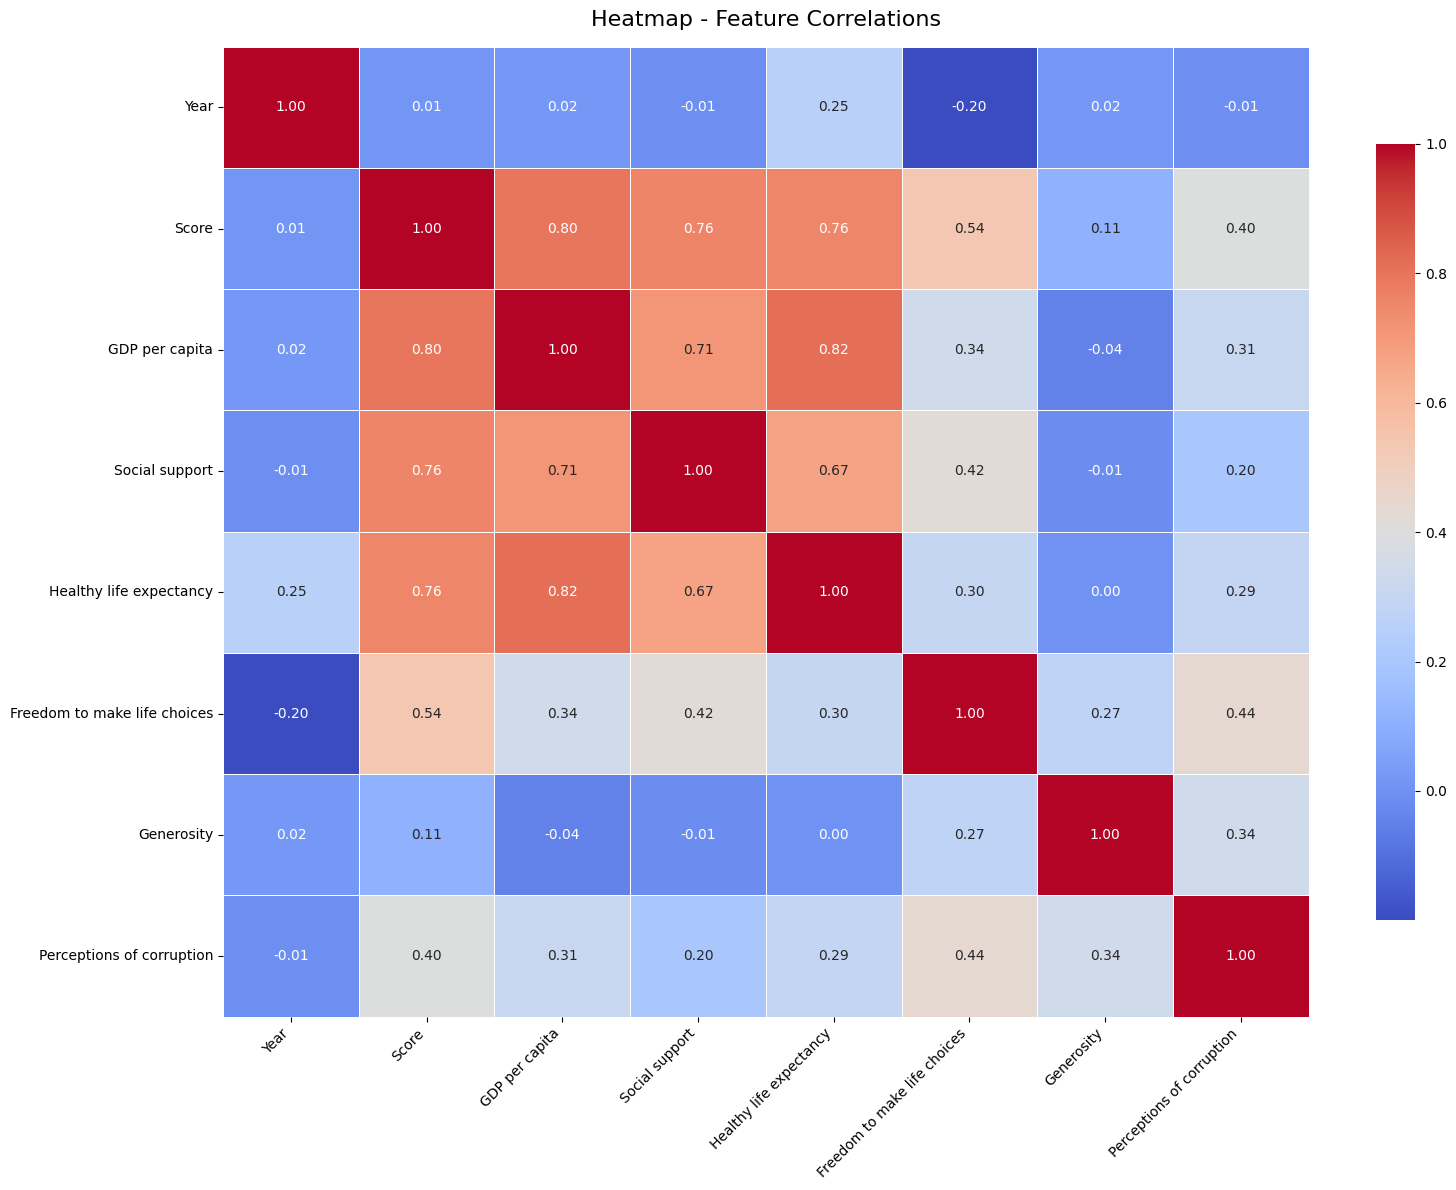

In [ ]:
plt.figure(figsize=(16, 12))

# نختار الأعمدة الرقمية فقط
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":10},
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Heatmap - Feature Correlations', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1036559058.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Happiness Level', y=col, data=df, palette='coolwarm', ci=None)
/tmp/ipython-input-1036559058.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Happiness Level', y=col, data=df, palette='coolwarm', ci=None)
/tmp/ipython-input-1036559058.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Happiness Level', y=col, data=df, palette='coolwarm', ci=None)
/tmp/ipython-input-1036559058.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Happiness Level', y=col, data=df, palette='

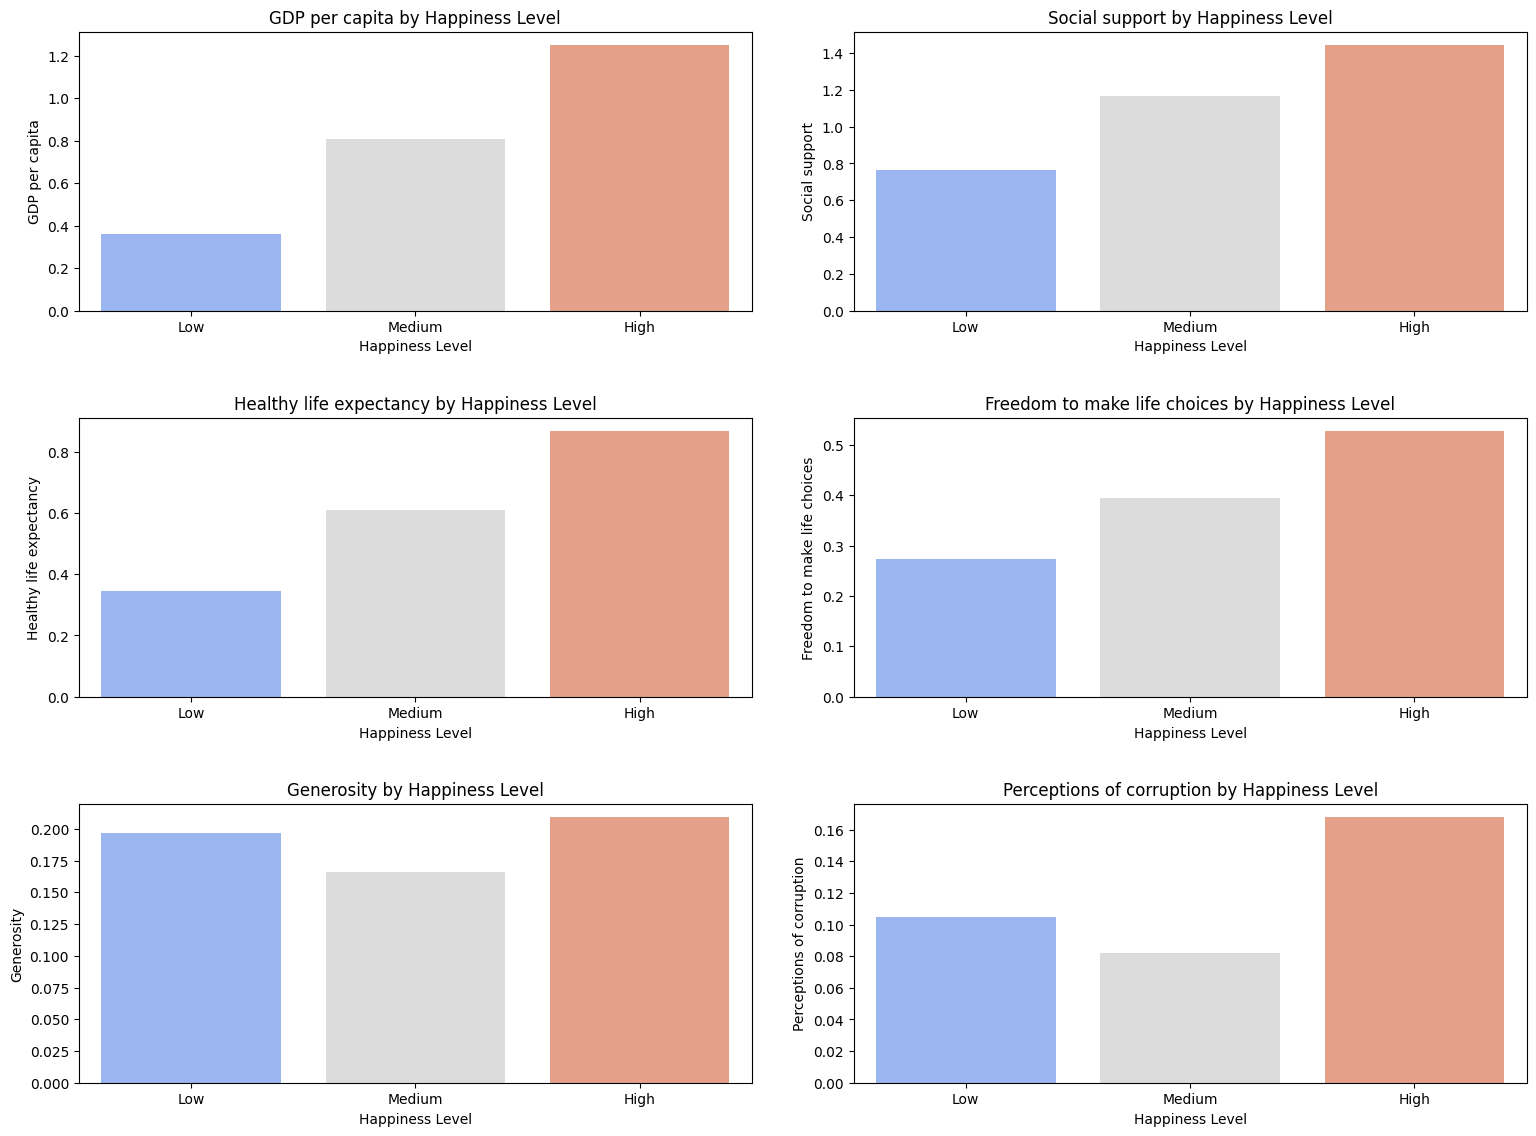

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تقسيم السعادة إلى فئات (Low, Medium, High)
df['Happiness Level'] = pd.cut(df['Score'],
                               bins=[0, 4, 6, 10],
                               labels=['Low', 'Medium', 'High'])

important_features = [
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(important_features, 1):
    plt.subplot(3, 2, i)
    sns.barplot(x='Happiness Level', y=col, data=df, palette='coolwarm', ci=None)
    plt.title(f'{col} by Happiness Level', fontsize=12)
    plt.xlabel('Happiness Level')
    plt.ylabel(col)

plt.tight_layout(pad=3)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Score'])
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop non-numeric columns before scaling
non_numeric_cols = ['Happiness Category', 'Happiness Level']
X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

# Store column names before scaling
feature_names = X_train.columns

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# تقييم بعد التحسين
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Optimized Random Forest → RMSE={rmse:.3f}, R²={r2:.3f}")

Optimized Random Forest → RMSE=0.493, R²=0.771


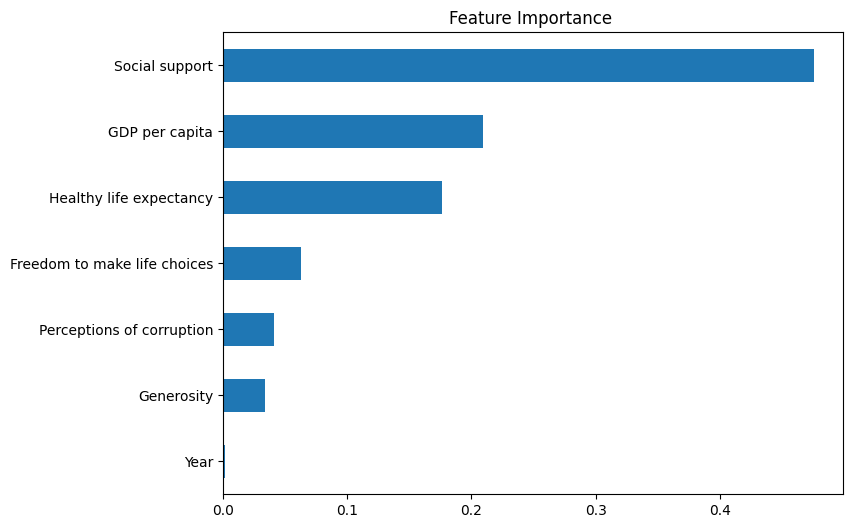

In [ ]:

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)


leak_cols = ['Overall rank']
X_train_df = X_train_df.drop(columns=leak_cols, errors='ignore')
X_test_df  = X_test_df.drop(columns=leak_cols, errors='ignore')


best_model.fit(X_train_df, y_train)


importances = pd.Series(best_model.feature_importances_, index=X_train_df.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance ")
plt.show()


In [ ]:
# ===== ElasticNet + GridSearchCV (Fine-Tuning) =====
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Pipeline: Scaling -> ElasticNet
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('en', ElasticNet(max_iter=10000, random_state=42))
])

# شبكة البحث (تقدرين توسعينها لاحقًا)
param_grid_en = {
    'en__alpha':     np.logspace(-3, 1, 9),   # 0.001 .. 10
    'en__l1_ratio':  [0.1, 0.3, 0.5, 0.7, 0.9]
}

en_grid = GridSearchCV(
    estimator=en_pipe,
    param_grid=param_grid_en,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# تدريب + اختيار الأفضل
en_grid.fit(X_train, y_train)
best_en = en_grid.best_estimator_
print("✅ Best ElasticNet Params:", en_grid.best_params_)

# التنبؤ + التقييم
y_pred_en = best_en.predict(X_test)
en_r2   = r2_score(y_test, y_pred_en)
en_rmse = np.sqrt(mean_squared_error(y_test, y_pred_en))
en_mae  = mean_absolute_error(y_test, y_pred_en)

print("\n🔹 ElasticNet (tuned) Performance")
print(f"R²   = {en_r2:.3f}")
print(f"RMSE = {en_rmse:.3f}")
print(f"MAE  = {en_mae:.3f}")

# صف للمقارنة النهائية
en_row = pd.DataFrame([{'Model':'ElasticNet (tuned)', 'R2':en_r2, 'RMSE':en_rmse, 'MAE':en_mae}])


Fitting 5 folds for each of 45 candidates, totalling 225 fits
✅ Best ElasticNet Params: {'en__alpha': np.float64(0.1), 'en__l1_ratio': 0.1}

🔹 ElasticNet (tuned) Performance
R²   = 0.745
RMSE = 0.520
MAE  = 0.412


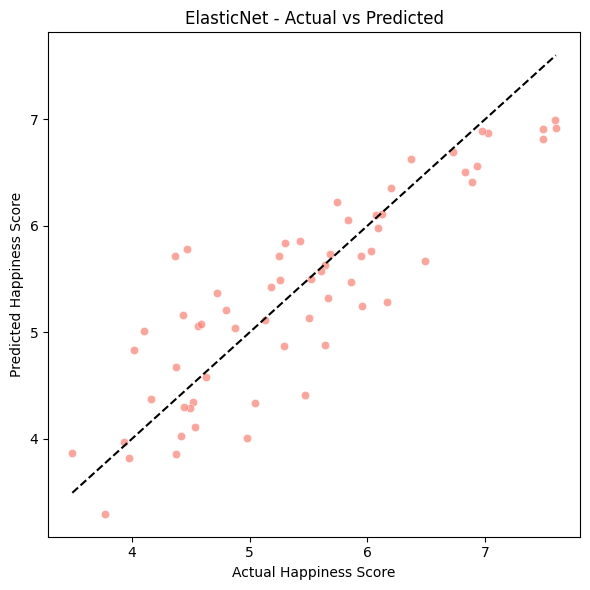

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_en, alpha=0.7, color='salmon')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k')  # خط مثالي للتنبؤ المثالي
plt.title("ElasticNet - Actual vs Predicted")
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.tight_layout()
plt.show()


In [ ]:
results = pd.DataFrame([
    {'Model': 'Random Forest',      'R2': r2,       'RMSE': rmse,       'MAE': mae},
    {'Model': 'ElasticNet (tuned)', 'R2': en_r2,    'RMSE': en_rmse,    'MAE': en_mae}
])

print("\n=== Model Comparison ===")
print(results)

# حفظ النتائج
results.to_csv('model_comparison.csv', index=False)



=== Model Comparison ===
                Model        R2      RMSE       MAE
0       Random Forest  0.771154  0.492554  0.348309
1  ElasticNet (tuned)  0.745318  0.519614  0.412429
